Obs: Converter em um arquivo .py para rodar.

# Importações

In [24]:
import abc

import argparse
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import warnings

from keras.src.layers import LSTM, Dense
from matplotlib.ticker import FuncFormatter
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

from pyESN import ESN

import tensorflow as tf

from keras import Sequential, Input
from pyswarms.single import GlobalBestPSO
from sklearn.model_selection import TimeSeriesSplit

from anneal import Annealer

MODELOS = ["ESN", "LSTM", "MLP", "RF", "XGBoost"]
SEEDS = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
OTIMIZADORES = ["PSO", "SA"]
N_CLASSES = [2, 3, 4, 5, 6, 7, 8, 9, 10]
N_ITER = 15
N_SOLUCOES = 15
SEED = 100
CAMPUS_TREINO = "PARANAGUÁ"
K_FOLDS = 5

warnings.filterwarnings('ignore')


def reset_seed(rnd_seed=SEED):
    os.environ['PYTHONHASHSEED'] = '0'
    random.seed(rnd_seed)
    np.random.seed(rnd_seed)
    tf.random.set_seed(rnd_seed)


reset_seed()


# Configuração dos Otimizadores
## Otimizador Base

In [25]:
class Otimizador:

    @abc.abstractmethod
    def __init__(self, dataset, features, n_solucoes, n_iteracoes, seed=SEED):
        reset_seed(seed)
        self.nome_modelo = None
        self.dataset = dataset
        self.features = features
        self.seed = seed
        self.n_solucoes = n_solucoes
        self.n_iteracoes = n_iteracoes
        self.solucoes = []
        self.iteracoes = []

    @abc.abstractmethod
    def run(self):
        pass

    @abc.abstractmethod
    def run_objective_function(self, parametros):
        pass

    def objective_function(self, modelo, parametros):
        dataset_treino = self.dataset[self.dataset["CAMPUS"] == CAMPUS_TREINO].copy()
        cvs = []
        for i_treino, i_teste in TimeSeriesSplit(n_splits=K_FOLDS, test_size=1).split(dataset_treino):
            # Treinamento com apenas o campus com a maior quantidade de dados
            x_treino = dataset_treino[self.features].iloc[i_treino].astype(np.float32).to_numpy()
            y_treino = dataset_treino["CLASSE"].iloc[i_treino].to_numpy()

            # Teste com os dados de todos os campus
            data_teste = dataset_treino.iloc[i_teste]["DATA"].values[0]
            df_teste = self.dataset.loc[self.dataset["DATA"] == data_teste]
            x_teste = df_teste[self.features].astype(np.float32).to_numpy()
            y_teste = df_teste["CLASSE"].to_numpy()

            if (isinstance(modelo, RandomForestClassifier)
                    or isinstance(modelo, XGBClassifier)
                    or isinstance(modelo, MLPClassifier)):
                modelo.fit(x_treino, y_treino)
                y_previsto = modelo.predict(x_teste)
            elif isinstance(modelo, ESN):
                modelo.fit(x_treino, OneHotEncoder(sparse_output=False).fit_transform(y_treino.reshape(-1, 1)))
                y_previsto = [np.argmax(val) for val in modelo.predict(x_teste)]
            else:
                modelo.fit(x_treino, y_treino, shuffle=False, verbose=0, epochs=parametros.epochs,
                           batch_size=parametros.batch_size)
                y_previsto = [np.argmax(val) for val in modelo.predict(x_teste, verbose=0)]

            cvs.append(accuracy_score(y_teste, y_previsto))

        return np.array(cvs).mean() * - 1

    def iteracoes_dataframe(self):
        df = pd.DataFrame()
        for i in range(len(self.iteracoes)):
            part = self.iteracoes[i]
            df = pd.concat([df, pd.DataFrame.from_dict(part.to_dict(), orient='index').T], ignore_index=True)
        return df

    def salvar_csv(self):
        pd_df = self.iteracoes_dataframe()
        pd_df.to_csv(f"resultados/otimização - classificação/{self.nome_modelo} SEED {self.seed}.csv", sep=";",
                     decimal=".",
                     index=True)


### ESN

In [26]:
class SolucaoESN:
    def __init__(self):
        self.fitness = None
        self.n_reservoirs = 0
        self.sparsity = 0
        self.spectral_radius = 0

    def to_dict(self):
        return {
            "Reservoirs": self.n_reservoirs,
            "Sparsity": self.sparsity,
            "Spectral Radius": self.spectral_radius,
            "Fitness": self.fitness,
        }

### LSTM

In [27]:
class SolucaoLSTM:
    def __init_(self):
        self.fitness = None
        self.lstm_units = 0
        self.epochs = 0
        self.batch_size = 0
        self.lstm_activation = None

    def to_dict(self):
        return {
            "Units": self.lstm_units,
            "Epochs": self.epochs,
            "Batch Size": self.batch_size,
            "Activation": self.lstm_activation,
            "Fitness": self.fitness,
        }


### MLP

In [28]:
class SolucaoMLP:
    def __init_(self):
        self.fitness = None
        self.hidden_layer_sizes = 0
        self.alpha = 0
        self.activation = None

    def to_dict(self):
        return {
            "Hidden Layers": self.hidden_layer_sizes,
            "Alpha": self.alpha,
            "Activation": self.activation,
            "Fitness": self.fitness,
        }


### Random Forest

In [29]:
class SolucaoRF:
    def __init_(self):
        self.fitness = None
        self.estimators = 0
        self.max_depth = 0
        self.min_samples_split = 0
        self.min_samples_leaf = 0

    def to_dict(self):
        return {
            "N_estimators": self.estimators,
            "Max_depth": self.max_depth,
            "Min_samples_split": self.min_samples_split,
            "Min_samples_leaf": self.min_samples_leaf,
            "Fitness": self.fitness,
        }

### XGBoost

In [30]:
class SolucaoXGB:
    def __init_(self):
        self.fitness = None
        self.estimators = 0
        self.max_depth = 0
        self.booster = None
        self.reg_lambda = 0
        self.reg_alpha = 0

    def to_dict(self):
        return {
            "N_estimators": self.estimators,
            "Max_depth": self.max_depth,
            "Booster": self.booster,
            "Lambda": self.reg_lambda,
            "Alpha": self.reg_alpha,
            "Fitness": self.fitness,
        }


## Simulated Annealing (SA)

In [31]:
class SimulatedAnneal(Annealer):
    def __init__(self, params, objective_function, max_iter):
        self.params = params
        self.objective_function = objective_function
        super().__init__(self.random_initial_state())
        self.steps = max_iter
        self.Tmin = 0.0001
        self.Tmax = 1
        self.updates = 0
        self.anneal()

    def random_initial_state(self):
        initial_state = {}
        for key in self.params.keys():
            initial_state[key] = random.choice(self.params[key])
        return initial_state

    def move(self):
        atual = self.state
        for key in self.params.keys():
            valor = atual[key]
            opcoes = len(self.params[key])
            if opcoes <= 2:
                self.state[key] = random.choice(self.params[key])
            else:
                intervalo = int(np.round(self.T * opcoes))
                diferencas = np.abs(np.array(self.params[key]) - valor)
                index = np.argmin(diferencas)
                inicio = max(0, index - intervalo)
                fim = min(opcoes - 1, index + intervalo)
                if inicio == fim:
                    self.state[key] = self.params[key][inicio]
                else:
                    self.state[key] = self.params[key][random.choice(range(inicio, fim))]

    def energy(self):
        return self.objective_function(self.state)

### ESN

In [32]:
class SAESN(Otimizador):

    def __init__(self, dataset, features, n_solucoes, n_iteracoes, seed=SEED):
        super().__init__(dataset, features, n_solucoes, n_iteracoes, seed)
        self.nome_modelo = "SA-ESN"
        self.run()

    def run(self):
        parametros = {
            "n_reservoirs": range(10, 400),
            "sparsity": np.arange(0.001, 0.8, 0.001),
            "spectral_radius": np.arange(0.001, 0.8, 0.001),
        }
        SimulatedAnneal(parametros, self.run_objective_function, max_iter=self.n_iteracoes * self.n_solucoes)

    def run_objective_function(self, parametros):
        solucao = SolucaoESN()
        solucao.n_reservoirs = int(parametros["n_reservoirs"])
        solucao.sparsity = np.round(parametros["sparsity"], 4)
        solucao.spectral_radius = np.round(parametros["spectral_radius"], 4)

        search = list(filter(lambda par:
                             par.n_reservoirs == solucao.n_reservoirs and
                             par.sparsity == solucao.sparsity and
                             par.spectral_radius == solucao.spectral_radius, self.solucoes))

        if search:
            solucao = search[0]

        else:
            modelo = ESN(n_inputs=self.dataset[self.features].shape[1],
                         n_outputs=self.dataset["CLASSE"].nunique(),
                         n_reservoir=solucao.n_reservoirs,
                         sparsity=solucao.sparsity,
                         spectral_radius=solucao.spectral_radius,
                         random_state=self.seed)

            solucao.fitness = self.objective_function(modelo, solucao)

        self.solucoes.append(solucao)

        self.solucoes = sorted(self.solucoes, key=lambda a: a.fitness)
        best = self.solucoes[0]
        self.iteracoes.append(best)
        self.salvar_csv()

        return solucao.fitness

### LSTM

In [33]:
class SALSTM(Otimizador):
    def __init__(self, dataset, features, n_solucoes, n_iteracoes, seed=SEED):
        super().__init__(dataset, features, n_solucoes, n_iteracoes, seed)
        self.nome_modelo = "SA-LSTM"
        self.ACTIVATIONS = ["linear", "mish", "sigmoid", "softmax", "softplus", "softsign", "tanh"]
        self.run()

    def run(self):
        parametros = {
            "lstm_units": range(10, 400),
            "epochs": range(10, 400),
            "batch_size": range(10, 400),
            "lstm_activation": range(0, 7),
        }
        SimulatedAnneal(parametros, self.run_objective_function, max_iter=self.n_iteracoes * self.n_solucoes)

    def run_objective_function(self, parametros):
        solucao = SolucaoLSTM()
        solucao.lstm_units = int(parametros["lstm_units"])
        solucao.epochs = int(parametros["epochs"])
        solucao.batch_size = int(parametros["batch_size"])
        solucao.lstm_activation = self.ACTIVATIONS[int(parametros["lstm_activation"])]

        search = list(filter(lambda par:
                             par.lstm_units == solucao.lstm_units and
                             par.epochs == solucao.epochs and
                             par.batch_size == solucao.batch_size and
                             par.lstm_activation == solucao.lstm_activation, self.solucoes))

        if search:
            solucao = search[0]

        else:
            tf.keras.backend.clear_session()
            modelo = Sequential([
                Input((self.dataset[self.features].shape[1], 1)),
                LSTM(solucao.lstm_units,
                     activation=solucao.lstm_activation,
                     seed=self.seed),
                Dense(self.dataset["CLASSE"].nunique(), activation="softmax"),
            ])
            modelo.compile(loss='sparse_categorical_crossentropy',
                           metrics=['accuracy'])

            solucao.fitness = self.objective_function(modelo, solucao)

        self.solucoes.append(solucao)

        self.solucoes = sorted(self.solucoes, key=lambda a: a.fitness)
        best = self.solucoes[0]
        self.iteracoes.append(best)
        self.salvar_csv()

        return solucao.fitness

### MLP

In [34]:
class SAMLP(Otimizador):
    def __init__(self, dataset, features, n_solucoes, n_iteracoes, seed=SEED):
        super().__init__(dataset, features, n_solucoes, n_iteracoes, seed)
        self.nome_modelo = "SA-MLP"
        self.ACTIVATIONS = ["identity", "logistic", "tanh", "relu"]
        self.run()

    def run(self):
        parametros = {
            "hidden_layer_sizes": range(10, 400),
            "alpha": np.arange(0, 1, 0.01),
            "activation": range(0, 4),
        }
        SimulatedAnneal(parametros, self.run_objective_function, max_iter=self.n_iteracoes * self.n_solucoes)

    def run_objective_function(self, parametros):
        solucao = SolucaoMLP()
        solucao.hidden_layer_sizes = int(parametros["hidden_layer_sizes"])
        solucao.alpha = round(parametros["alpha"], 4)
        solucao.activation = self.ACTIVATIONS[int(parametros["activation"])]

        search = list(filter(lambda par:
                             par.hidden_layer_sizes == solucao.hidden_layer_sizes and
                             par.alpha == solucao.alpha and
                             par.activation == solucao.activation, self.solucoes))

        if search:
            solucao = search[0]

        else:
            modelo = MLPClassifier(hidden_layer_sizes=(solucao.hidden_layer_sizes,),
                                   activation=solucao.activation,
                                   alpha=solucao.alpha,
                                   random_state=self.seed)

            solucao.fitness = self.objective_function(modelo, solucao)

        self.solucoes.append(solucao)

        self.solucoes = sorted(self.solucoes, key=lambda a: a.fitness)
        best = self.solucoes[0]
        self.iteracoes.append(best)
        self.salvar_csv()

        return solucao.fitness

### Random Forest


In [35]:
class SARF(Otimizador):
    def __init__(self, dataset, features, n_solucoes, n_iteracoes, seed=SEED):
        super().__init__(dataset, features, n_solucoes, n_iteracoes, seed)
        self.nome_modelo = "SA-RF"
        self.run()

    def run(self):
        parametros = {
            "estimators": range(10, 400),
            "max_depth": range(10, 400),
            "min_samples_split": range(2, 50),
            "min_samples_leaf": range(2, 50),
        }
        SimulatedAnneal(parametros, self.run_objective_function, max_iter=self.n_iteracoes * self.n_solucoes)

    def run_objective_function(self, parametros):
        solucao = SolucaoRF()
        solucao.estimators = int(parametros["estimators"])
        solucao.max_depth = int(parametros["max_depth"])
        solucao.min_samples_split = int(parametros["min_samples_split"])
        solucao.min_samples_leaf = int(parametros["min_samples_leaf"])

        search = list(filter(lambda par:
                             par.estimators == solucao.estimators and
                             par.max_depth == solucao.max_depth and
                             par.min_samples_split == solucao.min_samples_split and
                             par.min_samples_leaf == solucao.min_samples_leaf, self.solucoes))

        if search:
            solucao = search[0]

        else:
            modelo = RandomForestClassifier(random_state=self.seed,
                                            n_estimators=solucao.estimators,
                                            max_depth=solucao.max_depth,
                                            min_samples_split=solucao.min_samples_split,
                                            min_samples_leaf=solucao.min_samples_leaf)

            solucao.fitness = self.objective_function(modelo, solucao)

        self.solucoes.append(solucao)

        self.solucoes = sorted(self.solucoes, key=lambda a: a.fitness)
        best = self.solucoes[0]
        self.iteracoes.append(best)
        self.salvar_csv()

        return solucao.fitness


### XGBoost

In [36]:
class SAXGB(Otimizador):
    def __init__(self, dataset, features, n_solucoes, n_iteracoes, seed=SEED):
        super().__init__(dataset, features, n_solucoes, n_iteracoes, seed)
        self.nome_modelo = "SA-XGBoost"
        self.BOOSTERS = ["gbtree", "gblinear", "dart"]
        self.run()

    def run(self):
        parametros = {
            "estimators": range(10, 400),
            "max_depth": range(10, 400),
            "booster": range(0, 2),
            "reg_lambda": np.arange(0, 1, 0.005),
            "reg_alpha": np.arange(0, 1, 0.005),
        }
        SimulatedAnneal(parametros, self.run_objective_function, max_iter=self.n_iteracoes * self.n_solucoes)

    def run_objective_function(self, parametros):
        solucao = SolucaoXGB()
        solucao.estimators = int(parametros["estimators"])
        solucao.max_depth = int(parametros["max_depth"])
        solucao.booster = self.BOOSTERS[int(parametros["booster"])]
        solucao.reg_lambda = float(parametros["reg_lambda"])
        solucao.reg_alpha = float(parametros["reg_alpha"])

        search = list(filter(lambda par:
                             par.estimators == solucao.estimators and
                             par.max_depth == solucao.max_depth and
                             par.booster == solucao.booster and
                             par.reg_lambda == solucao.reg_lambda and
                             par.reg_alpha == solucao.reg_alpha, self.solucoes))

        if search:
            solucao = search[0]

        else:
            updater = "coord_descent" if solucao.booster == "gblinear" else None
            modelo = XGBClassifier(random_state=self.seed,
                                   n_estimators=solucao.estimators,
                                   max_depth=solucao.max_depth,
                                   booster=solucao.booster,
                                   reg_lambda=solucao.reg_lambda,
                                   reg_alpha=solucao.reg_alpha,
                                   updater=updater)

            solucao.fitness = self.objective_function(modelo, solucao)

        self.solucoes.append(solucao)

        self.solucoes = sorted(self.solucoes, key=lambda a: a.fitness)
        best = self.solucoes[0]
        self.iteracoes.append(best)
        self.salvar_csv()

        return solucao.fitness

## Particle Swarm Optimization (PSO)

### ESN

In [37]:
class PSOESN(Otimizador):
    def __init__(self, dataset, features, n_solucoes, n_iteracoes, seed=SEED):
        super().__init__(dataset, features, n_solucoes, n_iteracoes, seed)
        self.nome_modelo = "PSO-ESN"
        self.run()

    def run(self):
        lower_bound = [10, 0.001, 0.001]
        uppper_bound = [400, 0.8, 0.8]
        bounds = (lower_bound, uppper_bound)

        options = {'c1': 0.5, 'c2': 0.5, 'w': 0.5}
        optimizer = GlobalBestPSO(n_particles=self.n_solucoes,
                                  dimensions=3,
                                  options=options,
                                  bounds=bounds)

        optimizer.optimize(self.get_fitness, iters=self.n_iteracoes)

    def get_fitness(self, parts):
        fit_lst = [self.run_objective_function(parts[j]) for j in range(self.n_solucoes)]

        self.solucoes = sorted(self.solucoes, key=lambda a: a.fitness)
        best = self.solucoes[0]
        self.iteracoes.append(best)
        self.salvar_csv()

        return fit_lst

    def run_objective_function(self, particle_arr):
        solucao = SolucaoESN()
        solucao.n_reservoirs = int(particle_arr[0])
        solucao.sparsity = round(particle_arr[1], 4)
        solucao.spectral_radius = round(particle_arr[2], 4)

        search = list(filter(lambda par:
                             par.n_reservoirs == solucao.n_reservoirs and
                             par.sparsity == solucao.sparsity and
                             par.spectral_radius == solucao.spectral_radius, self.solucoes))

        if search:
            self.solucoes.append(search[0])
            return search[0].fitness

        modelo = ESN(n_inputs=self.dataset[self.features].shape[1],
                     n_outputs=self.dataset["CLASSE"].nunique(),
                     n_reservoir=solucao.n_reservoirs,
                     sparsity=solucao.sparsity,
                     spectral_radius=solucao.spectral_radius,
                     random_state=self.seed)

        solucao.fitness = self.objective_function(modelo, solucao)

        self.solucoes.append(solucao)

        return solucao.fitness


### LSTM

In [38]:
class PSOLSTM(Otimizador):
    def __init__(self, dataset, features, n_solucoes, n_iteracoes, seed=SEED):
        super().__init__(dataset, features, n_solucoes, n_iteracoes, seed)
        self.nome_modelo = "PSO-LSTM"
        self.ACTIVATIONS = ["linear", "mish", "sigmoid", "softmax", "softplus", "softsign", "tanh"]
        self.run()

    def run(self):
        lower_bound = [10, 10, 10, 0]
        uppper_bound = [400, 400, 400, 7]
        bounds = (lower_bound, uppper_bound)

        options = {'c1': 0.5, 'c2': 0.5, 'w': 0.5}
        optimizer = GlobalBestPSO(n_particles=self.n_solucoes,
                                  dimensions=4,
                                  options=options,
                                  bounds=bounds)

        optimizer.optimize(self.get_fitness, iters=self.n_iteracoes)

    def get_fitness(self, parts):
        fit_lst = [self.run_objective_function(parts[j]) for j in range(self.n_solucoes)]

        self.solucoes = sorted(self.solucoes, key=lambda a: a.fitness)
        best = self.solucoes[0]
        self.iteracoes.append(best)
        self.salvar_csv()

        return fit_lst

    def run_objective_function(self, particle_arr):
        solucao = SolucaoLSTM()
        solucao.lstm_units = int(particle_arr[0])
        solucao.epochs = int(particle_arr[1])
        solucao.batch_size = int(particle_arr[2])
        solucao.lstm_activation = self.ACTIVATIONS[int(particle_arr[3])]

        search = list(filter(lambda par:
                             par.lstm_units == solucao.lstm_units and
                             par.epochs == solucao.epochs and
                             par.batch_size == solucao.batch_size and
                             par.lstm_activation == solucao.lstm_activation, self.solucoes))

        if search:
            self.solucoes.append(search[0])
            return search[0].fitness
        tf.keras.backend.clear_session()
        modelo = Sequential([
            Input((self.dataset[self.features].shape[1], 1)),
            LSTM(solucao.lstm_units,
                 activation=solucao.lstm_activation,
                 seed=self.seed),
            Dense(self.dataset["CLASSE"].nunique(), activation="softmax"),
        ])
        modelo.compile(loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

        solucao.fitness = self.objective_function(modelo, solucao)

        self.solucoes.append(solucao)

        return solucao.fitness

### MLP

In [39]:
class PSOMLP(Otimizador):
    def __init__(self, dataset, features, n_solucoes, n_iteracoes, seed=SEED):
        super().__init__(dataset, features, n_solucoes, n_iteracoes, seed)
        self.nome_modelo = "PSO-MLP"
        self.ACTIVATIONS = ["identity", "logistic", "tanh", "relu"]
        self.run()

    def run(self):
        lower_bound = [10, 0, 0]
        uppper_bound = [400, 1.0, 4]
        bounds = (lower_bound, uppper_bound)

        options = {'c1': 0.5, 'c2': 0.5, 'w': 0.5}
        optimizer = GlobalBestPSO(n_particles=self.n_solucoes,
                                  dimensions=3,
                                  options=options,
                                  bounds=bounds)

        optimizer.optimize(self.get_fitness, iters=self.n_iteracoes)

    def get_fitness(self, parts):
        fit_lst = [self.run_objective_function(parts[j]) for j in range(self.n_solucoes)]

        self.solucoes = sorted(self.solucoes, key=lambda a: a.fitness)
        best = self.solucoes[0]
        self.iteracoes.append(best)
        self.salvar_csv()

        return fit_lst

    def run_objective_function(self, particle_arr):
        solucao = SolucaoMLP()
        solucao.hidden_layer_sizes = int(particle_arr[0])
        solucao.alpha = particle_arr[1]
        solucao.activation = self.ACTIVATIONS[int(particle_arr[2])]

        search = list(filter(lambda par:
                             par.hidden_layer_sizes == solucao.hidden_layer_sizes and
                             par.alpha == solucao.alpha and
                             par.activation == solucao.activation, self.solucoes))

        if search:
            self.solucoes.append(search[0])
            return search[0].fitness

        modelo = MLPClassifier(hidden_layer_sizes=(solucao.hidden_layer_sizes,),
                               activation=solucao.activation,
                               alpha=solucao.alpha,
                               random_state=self.seed)

        solucao.fitness = self.objective_function(modelo, solucao)

        self.solucoes.append(solucao)

        return solucao.fitness

### Random Forest


In [40]:
class PSORF(Otimizador):
    def __init__(self, dataset, features, n_solucoes, n_iteracoes, seed=SEED):
        super().__init__(dataset, features, n_solucoes, n_iteracoes, seed)
        self.nome_modelo = "PSO-RF"
        self.run()

    def run(self):
        lower_bound = [10, 10, 2, 2]
        uppper_bound = [400, 400, 50, 50]
        bounds = (lower_bound, uppper_bound)

        options = {'c1': 0.5, 'c2': 0.5, 'w': 0.5}
        optimizer = GlobalBestPSO(n_particles=self.n_solucoes,
                                  dimensions=4,
                                  options=options,
                                  bounds=bounds)

        optimizer.optimize(self.get_fitness, iters=self.n_iteracoes)

    def get_fitness(self, parts):
        fit_lst = [self.run_objective_function(parts[j]) for j in range(self.n_solucoes)]

        self.solucoes = sorted(self.solucoes, key=lambda a: a.fitness)
        best = self.solucoes[0]
        self.iteracoes.append(best)
        self.salvar_csv()

        return fit_lst

    def run_objective_function(self, particle_arr):
        solucao = SolucaoRF()
        solucao.estimators = int(particle_arr[0])
        solucao.max_depth = int(particle_arr[1])
        solucao.min_samples_split = int(particle_arr[2])
        solucao.min_samples_leaf = int(particle_arr[3])

        search = list(filter(lambda par:
                             par.estimators == solucao.estimators and
                             par.max_depth == solucao.max_depth and
                             par.min_samples_split == solucao.min_samples_split and
                             par.min_samples_leaf == solucao.min_samples_leaf, self.solucoes))

        if search:
            self.solucoes.append(search[0])
            return search[0].fitness

        modelo = RandomForestClassifier(random_state=self.seed,
                                        n_estimators=solucao.estimators,
                                        max_depth=solucao.max_depth,
                                        min_samples_split=solucao.min_samples_split,
                                        min_samples_leaf=solucao.min_samples_leaf)

        solucao.fitness = self.objective_function(modelo, solucao)

        self.solucoes.append(solucao)

        return solucao.fitness


### XGBoost

In [41]:
class PSOXGB(Otimizador):
    def __init__(self, dataset, features, n_solucoes, n_iteracoes, seed=SEED):
        super().__init__(dataset, features, n_solucoes, n_iteracoes, seed)
        self.nome_modelo = "PSO-XGBoost"
        self.BOOSTERS = ["gbtree", "gblinear", "dart"]
        self.run()

    def run(self):
        lower_bound = [10, 10, 0, 0, 0]
        uppper_bound = [400, 400, 2, 1, 1]
        bounds = (lower_bound, uppper_bound)

        options = {'c1': 0.5, 'c2': 0.5, 'w': 0.5}
        optimizer = GlobalBestPSO(n_particles=self.n_solucoes,
                                  dimensions=5,
                                  options=options,
                                  bounds=bounds)

        optimizer.optimize(self.get_fitness, iters=self.n_iteracoes)

    def get_fitness(self, parts):
        fit_lst = [self.run_objective_function(parts[j]) for j in range(self.n_solucoes)]

        self.solucoes = sorted(self.solucoes, key=lambda a: a.fitness)
        best = self.solucoes[0]
        self.iteracoes.append(best)
        self.salvar_csv()

        return fit_lst

    def run_objective_function(self, particle_arr):
        solucao = SolucaoXGB()
        solucao.estimators = int(particle_arr[0])
        solucao.max_depth = int(particle_arr[1])
        solucao.booster = self.BOOSTERS[int(particle_arr[2])]
        solucao.reg_lambda = round(particle_arr[3], 4)
        solucao.reg_alpha = round(particle_arr[4], 4)

        search = list(filter(lambda par:
                             par.estimators == solucao.estimators and
                             par.max_depth == solucao.max_depth and
                             par.booster == solucao.booster and
                             par.reg_lambda == solucao.reg_lambda and
                             par.reg_alpha == solucao.reg_alpha, self.solucoes))

        if search:
            self.solucoes.append(search[0])
            return search[0].fitness

        updater = "coord_descent" if solucao.booster == "gblinear" else None
        modelo = XGBClassifier(random_state=self.seed,
                               n_estimators=solucao.estimators,
                               max_depth=solucao.max_depth,
                               booster=solucao.booster,
                               reg_lambda=solucao.reg_lambda,
                               reg_alpha=solucao.reg_alpha,
                               updater=updater)

        solucao.fitness = self.objective_function(modelo, solucao)

        self.solucoes.append(solucao)

        return solucao.fitness


# Carregar Datasets

In [42]:
parser = argparse.ArgumentParser(description="Otimização de modelos.")
parser.add_argument('--s', default=SEEDS[0], help="Semente.")
parser.add_argument('--o', default="PSO", help="Otimizador.")
parser.add_argument('--c', default=N_CLASSES[0], help="Número de Classes.")
parser.add_argument('--m', help="Modelo.")
parser.add_argument('--continua', default="1",
                    help="Continua a otimização do modelo com os demais otimizadores e sementes.")
args = parser.parse_args()

df_consumo = pd.read_csv(f"./dados/{args.c}_classes_normalizadas_lagadas.csv", sep=';', decimal='.')
df_features = pd.read_csv("resultados/features/fitness_features_regressao.csv", sep=";", decimal=".")

df_features = df_features.sort_values("RRMSE").head(1).reset_index(drop=True)
df_features = pd.DataFrame(
    columns=str(df_features.iloc[0]["FEATURES"]).replace("(", '').replace(")", '').replace("'", "").split(", "))

df_consumo = df_consumo.sort_values("CAMPUS").sort_values("DATA")
df_features = df_features.columns
df_features

Index(['TEMP_MÉD_ACC_MENS', 'TEMP_MIN_MAX_MENS', 'TEMP_MIN_ACC_MENS',
       'PRECIPITAÇÃO_MIN_MENS', 'TEMP_MAX_ACC_MENS', 'PRECIPITAÇÃO_MAX_MENS',
       'DIA_DA_SEMANA_sex', 'MÊS_abr', 'MÊS_jul', 'MÊS_mai', 'MÊS_mar',
       'ANO_2024', 'ANO_2015', 'ANO_2017', 'ANO_2020', 'ANO_2014',
       'CAMPUS_ARAPONGAS', 'CAMPUS_CAMPO LARGO', 'CAMPUS_COLOMBO',
       'CAMPUS_LONDRINA - CENTRO', 'CAMPUS_LONDRINA - NORTE',
       'CAMPUS_PARANAVAÍ', 'CAMPUS_QUEDAS DO IGUAÇU', 'CURSOS_GRAD_MATUTINO',
       'CURSOS_GRAD_VESPERTINO', 'FÉRIAS', 'COVID', 'ORDEM', 'LAG_01',
       'LAG_02', 'LAG_03', 'LAG_04', 'LAG_05', 'LAG_06', 'LAG_08', 'LAG_11',
       'LAG_12'],
      dtype='object')


# Execução da Otimização

In [52]:
# Executa a otimização dos modelos normalmente, e reinicia a execução do código para o modelo LSTM - em função de estouro de memória.

if args.m is not None:
    print(
        f"Executando a otimização com {args.c} classe usando o modelo {args.m} com o otimizador {args.o} e semente {args.s}.")
    if args.o == "PSO":
        if args.m == "ESN":
            PSOESN(df_consumo, df_features, N_SOLUCOES, N_ITER, int(args.s))
        elif args.m == "LSTM":
            PSOLSTM(df_consumo, df_features, N_SOLUCOES, N_ITER, int(args.s))
        elif args.m == "MLP":
            PSOMLP(df_consumo, df_features, N_SOLUCOES, N_ITER, int(args.s))
        elif args.m == "RF":
            PSORF(df_consumo, df_features, N_SOLUCOES, N_ITER, int(args.s))
        elif args.m == "XGBoost":
            PSOXGB(df_consumo, df_features, N_SOLUCOES, N_ITER, int(args.s))
        if args.continua == "1":
            os.execv(sys.executable,
                     [sys.executable,
                      *sys.argv,
                      '--s', str(args.s),
                      '--o', 'SA',
                      '--m', args.m,
                      '--continua', args.continua])
    elif args.o == "SA":
        if args.m == "ESN":
            SAESN(df_consumo, df_features, N_SOLUCOES, N_ITER, int(args.s))
        elif args.m == "LSTM":
            SALSTM(df_consumo, df_features, N_SOLUCOES, N_ITER, int(args.s))
        elif args.m == "MLP":
            SAMLP(df_consumo, df_features, N_SOLUCOES, N_ITER, int(args.s))
        elif args.m == "RF":
            SARF(df_consumo, df_features, N_SOLUCOES, N_ITER, int(args.s))
        elif args.m == "XGBoost":
            SAXGB(df_consumo, df_features, N_SOLUCOES, N_ITER, int(args.s))
        if args.continua == "1" and SEEDS.index(int(args.s)) < len(SEEDS) - 1:
            os.execv(sys.executable,
                     [sys.executable, *sys.argv,
                      '--s', str(SEEDS[SEEDS.index(int(args.s)) + 1]),
                      '--o', 'PSO',
                      '--m', args.m,
                      '--c', str(N_CLASSES[N_CLASSES.index(int(args.c)) + 1]),
                      '--continua', "1"])

else:
    print("Argumentos não informados. Executando a otimização dos modelos ESN, LSTM, MLP, RF e XGB.")
    for seed in SEEDS:
        PSOESN(df_consumo, df_features, N_SOLUCOES, N_ITER, seed)
        PSOMLP(df_consumo, df_features, N_SOLUCOES, N_ITER, seed)
        PSORF(df_consumo, df_features, N_SOLUCOES, N_ITER, seed)
        PSOXGB(df_consumo, df_features, N_SOLUCOES, N_ITER, seed)
        SAESN(df_consumo, df_features, N_SOLUCOES, N_ITER, seed)
        SAMLP(df_consumo, df_features, N_SOLUCOES, N_ITER, seed)
        SARF(df_consumo, df_features, N_SOLUCOES, N_ITER, seed)
        SAXGB(df_consumo, df_features, N_SOLUCOES, N_ITER, seed)
    os.execv(sys.executable,
             [sys.executable, *sys.argv,
              '--s', str(SEEDS[0]),
              '--o', 'PSO',
              '--m', 'LSTM',
              '--c', str(N_CLASSES[0]),
              '--continua', "1"])


2025-07-27 18:17:32,801 - pyswarms.single.global_best - INFO - Optimize for 3 iters with {'c1': 0.5, 'c2': 0.5, 'w': 0.5}
pyswarms.single.global_best:   0%|          |0/3

shapes (373,10) and (1,) not aligned: 10 (dim 1) != 1 (dim 0)
{'Reservoirs': 373, 'Sparsity': 0.3329, 'Spectral Radius': 0.0242, 'Fitness': None}
shapes (373,10) and (1,) not aligned: 10 (dim 1) != 1 (dim 0)
{'Reservoirs': 373, 'Sparsity': 0.3329, 'Spectral Radius': 0.0242, 'Fitness': None}
shapes (373,10) and (1,) not aligned: 10 (dim 1) != 1 (dim 0)
{'Reservoirs': 373, 'Sparsity': 0.3329, 'Spectral Radius': 0.0242, 'Fitness': None}
shapes (373,10) and (1,) not aligned: 10 (dim 1) != 1 (dim 0)
{'Reservoirs': 373, 'Sparsity': 0.3329, 'Spectral Radius': 0.0242, 'Fitness': None}
shapes (373,10) and (1,) not aligned: 10 (dim 1) != 1 (dim 0)
{'Reservoirs': 373, 'Sparsity': 0.3329, 'Spectral Radius': 0.0242, 'Fitness': None}
shapes (373,10) and (1,) not aligned: 10 (dim 1) != 1 (dim 0)
{'Reservoirs': 373, 'Sparsity': 0.3329, 'Spectral Radius': 0.0242, 'Fitness': None}
shapes (373,10) and (1,) not aligned: 10 (dim 1) != 1 (dim 0)
{'Reservoirs': 373, 'Sparsity': 0.3329, 'Spectral Radius': 0.0

pyswarms.single.global_best:   0%|          |0/3

shapes (373,10) and (1,) not aligned: 10 (dim 1) != 1 (dim 0)
{'Reservoirs': 373, 'Sparsity': 0.3329, 'Spectral Radius': 0.0242, 'Fitness': None}




KeyboardInterrupt



# Optimization Results
## Fitness Evolution

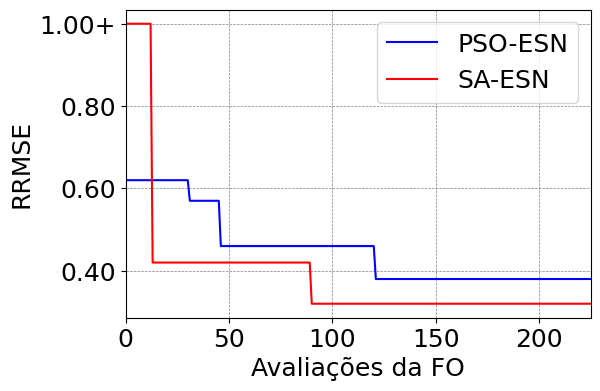

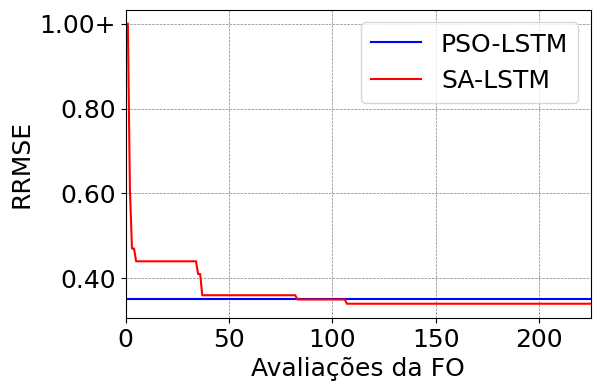

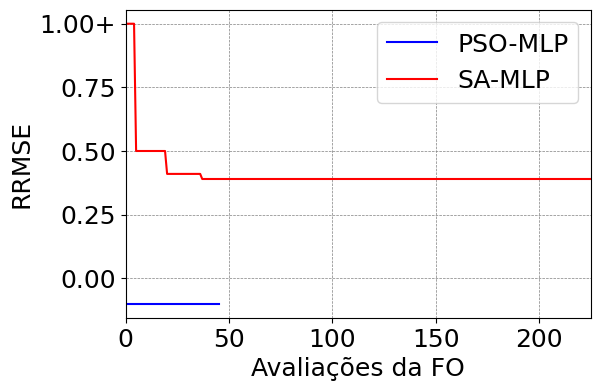

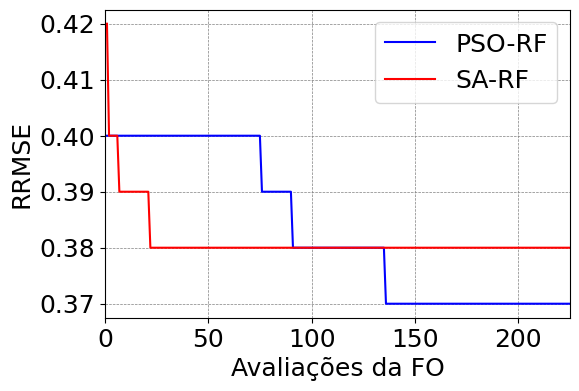

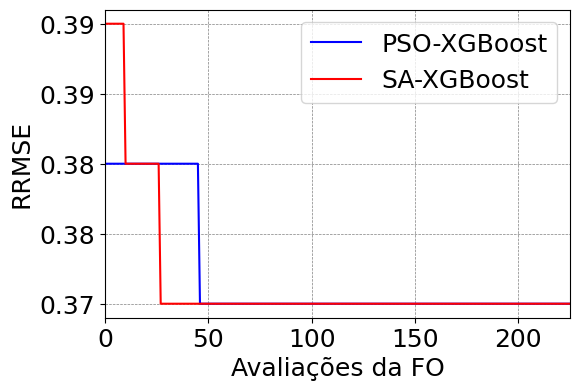

In [44]:
def formatar_y(valor, pos):
    if valor >= 1:
        return f"{valor:.2f}+"
    return f"{valor:.2f}"


for modelo in MODELOS:
    plt.figure(figsize=(6, 4))
    plt.rcParams['xtick.labelsize'] = 18
    plt.rcParams['ytick.labelsize'] = 18
    plt.rcParams.update({'font.size': 18})
    plt.rcParams['axes.prop_cycle'] = plt.cycler(
        color=["blue", "red"])

    for otimizador in OTIMIZADORES:
        df = pd.DataFrame()
        final_fitness = {}
        for seed in SEEDS:
            try:
                novo_df = pd.read_csv(f'resultados/otimização - classificação/{otimizador}-{modelo} SEED {seed}.csv',
                                      sep=";",
                                      decimal=".", header=0)
            except Exception as e:
                continue

            if otimizador == "PSO":
                df[seed] = pd.concat([novo_df["Fitness"].to_frame()] * N_ITER, ignore_index=True)
                df[seed] = sorted(df[seed].values, reverse=True)
            else:
                df[seed] = novo_df["Fitness"]
            df[seed] = np.where(df[seed] > 1, 1, df[seed])  # Limitar valores de Fitness a 1
            final_fitness[seed] = novo_df["Fitness"].iloc[-1]  # Último valor de Fitness para cada seed

        df = np.round(df, decimals=2)
        best_seed = min(final_fitness, key=final_fitness.get)
        plt.plot(range(1, len(df) + 1), [x for x in df[best_seed]], label=f"{otimizador}-{modelo}")

        plt.xlabel('Avaliações da FO')
        plt.ylabel('RRMSE')
        plt.gca().yaxis.set_major_formatter(FuncFormatter(formatar_y))
        plt.xlim(0, N_ITER * N_SOLUCOES)
        ax = plt.gca()
        ax.set_facecolor('white')
        plt.grid(True, color='grey', linestyle="--", linewidth=0.5)
        plt.legend(facecolor='white')
        plt.savefig(f"./resultados/otimização - classificação/{modelo}.png", bbox_inches='tight')
        plt.show()

## Best Params

In [45]:
best = {}
for modelo in ["ESN", "LSTM", "MLP", "RF", "XGBoost"]:
    df = pd.DataFrame()
    for otimizador in ["PSO", "SA"]:
        for seed in SEEDS:
            try:
                novo_df = pd.read_csv(f'resultados/otimização - classificação/{otimizador}-{modelo} SEED {seed}.csv',
                                      sep=";", decimal=".",
                                      header=0)
                df = pd.concat([df, novo_df], axis=0)
            except Exception as e:
                continue

    df = df.sort_values(by=["Fitness"])
    df[df.isnull()] = None
    best[f"{modelo}"] = df[:1]



### ESN

In [46]:
best["ESN"].transpose()

,171
Unnamed: 0,171.000000
Reservoirs,14.000000
Sparsity,0.414000
Spectral Radius,0.353000
Fitness,0.320256


### LSTM

In [47]:
best["LSTM"].transpose()

,160
Unnamed: 0,160
Units,368
Epochs,178
Batch Size,30
Activation,sigmoid
Fitness,0.343295


### MLP

In [48]:
best["MLP"].transpose()

,0
Unnamed: 0,0
Hidden Layers,151
Alpha,0.035106
Activation,relu
Fitness,-0.104167


### RF

In [49]:
best["RF"].transpose()

,14
Unnamed: 0,14.000000
N_estimators,21.000000
Max_depth,179.000000
Min_samples_split,28.000000
Min_samples_leaf,5.000000
Fitness,0.366958


### XGB

In [50]:
best["XGBoost"].transpose()

,156
Unnamed: 0,156
N_estimators,366
Max_depth,177
Booster,gbtree
Lambda,0.285
Alpha,0.1
Fitness,0.367669
